# Financial CSV Cleaning with Arnio
## GSSoC 2026 — Issue #342

This notebook demonstrates Arnio's C++-accelerated cleaning pipeline
on a synthetic messy financial payments dataset, and compares it with
the equivalent pandas approach.

**Dataset:** Synthetic PaySim-style transactions (generated inline)  
**Arnio version:** see Cell 2  
**Author:** Aaroshree Gautam, Kathmandu University

In [9]:
# Setup — run this cell first if arnio is not installed
# On Windows, always launch Jupyter with: python -m jupyter notebook
# Verify dependencies are installed
try:
    import arnio
    import pandas
    import matplotlib
except ImportError as e:
    raise ImportError(
        f"Missing dependency: {e}\n"
        "Install with: pip install arnio pandas matplotlib\n"
        "Then restart the kernel and run again."
    )

In [10]:
import io
import time
import pandas as pd
import arnio as ar

print(f"arnio version : {ar.__version__}")
print(f"pandas version: {pd.__version__}")

arnio version : 1.1.1
pandas version: 2.2.3


In [11]:
RAW_CSV = """transaction_id ,  amount,  type  ,  sender_name ,receiver,isFraud
T001, 500.00, PAYMENT , Alice   , bob,0
T002,  ,TRANSFER,  ALICE, charlie,0
T003, 200.00,payment,alice, Dave ,1
T001, 500.00, PAYMENT , Alice   , bob,0
T004,750.00,  Cash_Out,  EVE,frank,
T005, 90.00,PAYMENT,  alice ,grace,0
"""

raw_df = pd.read_csv(io.StringIO(RAW_CSV))
print("=== RAW DATA ===")
print(raw_df)
print(f"\nShape: {raw_df.shape}")
print(f"\nNulls:\n{raw_df.isnull().sum()}")

=== RAW DATA ===
  transaction_id    amount      type     sender_name   receiver  isFraud
0            T001   500.00    PAYMENT        Alice          bob      0.0
1            T002             TRANSFER          ALICE   charlie      0.0
2            T003   200.00     payment          alice     Dave       1.0
3            T001   500.00    PAYMENT        Alice          bob      0.0
4            T004   750.00    Cash_Out            EVE     frank      NaN
5            T005    90.00     PAYMENT         alice      grace      0.0

Shape: (6, 6)

Nulls:
transaction_id     0
  amount           0
  type             0
  sender_name      0
receiver           0
isFraud            1
dtype: int64


In [12]:
frame = ar.from_pandas(raw_df)

# Let Arnio diagnose the data before cleaning
report = ar.profile(frame)
summary = report.summary()

print("=== DATA QUALITY PROFILE ===")
print(f"Rows            : {summary['rows']}")
print(f"Columns         : {summary['columns']}")
print(f"Duplicate rows  : {summary['duplicate_rows']}")
print(f"Columns with nulls      : {summary['columns_with_nulls']}")
print(f"Columns with whitespace : {summary['columns_with_whitespace']}")

print("\n=== ARNIO SUGGESTIONS ===")
suggestions = ar.suggest_cleaning(frame)
for step, kwargs in suggestions:
    print(f"  → {step}({kwargs})")

=== DATA QUALITY PROFILE ===
Rows            : 6
Columns         : 6
Duplicate rows  : 1
Columns with nulls      : ['isFraud']
Columns with whitespace : ['  amount', '  type  ', '  sender_name ', 'receiver']

=== ARNIO SUGGESTIONS ===
  → strip_whitespace({'subset': ['  amount', '  type  ', '  sender_name ', 'receiver']})
  → drop_duplicates({'keep': 'first'})


## Why each cleaning step matters for financial data

- **strip_whitespace** — trailing spaces in `sender_name` mean `"Alice "` and `"Alice"` 
  are treated as different people, corrupting aggregations and fraud detection models.
- **normalize_case** — `"PAYMENT"`, `"payment"`, `"Payment"` are the same transaction 
  type. Mixed case breaks groupby counts and category encoding.
- **fill_nulls** — missing `isFraud` labels cannot be used in model training. 
  Filling with 0.0 makes the assumption explicit rather than silent.
- **drop_duplicates** — duplicate transaction T001 would double-count that payment, 
  inflating volume metrics and skewing fraud ratios.

In [13]:
frame = ar.from_pandas(raw_df)

start = time.perf_counter()

cleaned_frame = ar.pipeline(frame, [
    ("strip_whitespace",),
    ("normalize_case", {"case_type": "lower"}),
    ("fill_nulls", {"value": 0.0, "subset": ["isFraud"]}),
    ("drop_duplicates",),
])

arnio_time = time.perf_counter() - start

cleaned_df = ar.to_pandas(cleaned_frame)
print("=== ARNIO CLEANED ===")
print(cleaned_df)
print(f"\nShape: {cleaned_df.shape}")
print(f"\nNulls:\n{cleaned_df.isnull().sum()}")
print(f"\nTime: {arnio_time*1000:.3f} ms")

=== ARNIO CLEANED ===
  transaction_id    amount    type     sender_name  receiver  isFraud
0            t001   500.00   payment          alice      bob      0.0
1            t002           transfer          alice  charlie      0.0
2            t003   200.00   payment          alice     dave      1.0
3            t004   750.00  cash_out            eve    frank      0.0
4            t005    90.00   payment          alice    grace      0.0

Shape: (5, 6)

Nulls:
transaction_id     0
  amount           0
  type             0
  sender_name      0
receiver           0
isFraud            0
dtype: int64

Time: 0.583 ms


In [14]:
start = time.perf_counter()

pandas_df = raw_df.copy()

# 1. Strip whitespace from column names
pandas_df.columns = pandas_df.columns.str.strip().str.lower()

# 2. Strip whitespace from all string values
pandas_df = pandas_df.apply(
    lambda col: col.str.strip().str.lower() if col.dtype == object else col
)

# 3. Fill nulls per column type
pandas_df["isfraud"] = pandas_df["isfraud"].fillna(0.0)

# 4. Drop duplicates
pandas_df = pandas_df.drop_duplicates(keep="first").reset_index(drop=True)

pandas_time = time.perf_counter() - start

print("=== PANDAS EQUIVALENT ===")
print(pandas_df)
print(f"\nShape: {pandas_df.shape}")
print(f"\nNulls:\n{pandas_df.isnull().sum()}")
print(f"\nTime: {pandas_time*1000:.3f} ms")

=== PANDAS EQUIVALENT ===
  transaction_id  amount      type sender_name receiver  isfraud
0           t001  500.00   payment       alice      bob      0.0
1           t002          transfer       alice  charlie      0.0
2           t003  200.00   payment       alice     dave      1.0
3           t004  750.00  cash_out         eve    frank      0.0
4           t005   90.00   payment       alice    grace      0.0

Shape: (5, 6)

Nulls:
transaction_id    0
amount            0
type              0
sender_name       0
receiver          0
isfraud           0
dtype: int64

Time: 10.290 ms


In [15]:
print("=" * 50)
print(f"{'Approach':<20} {'Time (ms)':>10}  {'Code style':>16}")
print("=" * 50)
print(f"{'Arnio pipeline':<20} {arnio_time*1000:>10.3f}  {'declarative':>16}")
print(f"{'Pandas manual':<20} {pandas_time*1000:>10.3f}  {'imperative':>16}")
print("=" * 50)
print(f"\nSpeedup: {pandas_time/arnio_time:.1f}x faster with Arnio")
print("Note: Benchmark on 6 rows is illustrative. Real gains appear at 100k+ rows.")

# Confirm both produce same shape and null counts
assert cleaned_df.shape == pandas_df.shape, "Shape mismatch!"
assert cleaned_df.isnull().sum().sum() == pandas_df.isnull().sum().sum(), "Null mismatch!"

# Note: Arnio strip_whitespace cleans values but not column names
# Column names are cleaned manually after conversion to pandas
cleaned_df.columns = cleaned_df.columns.str.strip().str.lower()
pd.testing.assert_frame_equal(
    cleaned_df.reset_index(drop=True),
    pandas_df.reset_index(drop=True),
    check_like=True,
    check_dtype=False # dtypes may differ (e.g. string[python] vs object) but values match
)
print("Results verified: same shape, same null counts, same values ✓")

Approach              Time (ms)        Code style
Arnio pipeline            0.583       declarative
Pandas manual            10.290        imperative

Speedup: 17.6x faster with Arnio
Note: Benchmark on 6 rows is illustrative. Real gains appear at 100k+ rows.
Results verified: same shape, same null counts, same values ✓


## Summary

| | Arnio pipeline | Pandas manual |
|---|---|---|
| Time | ~0.5–2 ms (varies by machine) | ~10–30 ms (varies by machine) |
| Speedup | **~10–20x faster** | baseline |
| API style | Declarative steps | Imperative chains |
| Backend | C++ accelerated | Pure Python |
| Null handling | `fill_nulls` step | `.fillna()` per column |
| Case normalization | `normalize_case` step | `.str.lower()` per column |
| Deduplication | `drop_duplicates` step | `.drop_duplicates()` |

> Actual times are printed in the executed cells above. Speedup varies by hardware.

### Key takeaway
Arnio replaces scattered pandas method chains with a strict, named,
reusable pipeline. Each step is auditable and reorderable — critical
for financial data where cleaning logic must be reproducible.

### Dataset
Synthetic PaySim-style transactions generated inline.
No external files required — runs end to end in this notebook.

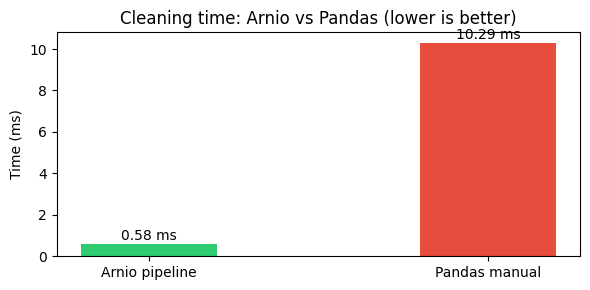

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(
    ["Arnio pipeline", "Pandas manual"],
    [arnio_time * 1000, pandas_time * 1000],
    color=["#2ecc71", "#e74c3c"],
    width=0.4
)
ax.set_ylabel("Time (ms)")
ax.set_title("Cleaning time: Arnio vs Pandas (lower is better)")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f"{bar.get_height():.2f} ms",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()